In [15]:
# import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# visualisation style
sns.set_style("whitegrid")

In [16]:
# colour mapping
typecolours = {
    "Normal": "#c4c4b8",
    "Fire": "#ffa06a",
    "Water": "#7bafff",
    "Grass": "#8ed66f",
    "Electric": "#ffe26b",
    "Ice": "#b5eae7",
    "Fighting": "#dc6b66",
    "Poison": "#be73bc",
    "Ground": "#e8d08d",
    "Flying": "#c1b3f9",
    "Psychic": "#fa82a7",
    "Bug": "#c2d16c",
    "Rock": "#d1c37b",
    "Ghost": "#9d8bb9",
    "Dragon": "#9973ff",
    "Dark": "#8e7d73",
    "Steel": "#cacad8",
    "Fairy": "#f5aedb"
}

In [17]:
# load dataset
path = "pokemon.csv"
df = pd.read_csv(path)

# shape and types
print(f"Shape of the dataset: {df.shape}")
print(f"\nData types:\n{df.dtypes}")

df["Colour"] = df["Type1"].map(typecolours)
df.loc[df["Type2"].notna(), "Colour"] = "#dca1e6"

Shape of the dataset: (809, 4)

Data types:
Name         str
Type1        str
Type2        str
Evolution    str
dtype: object


In [18]:
print("First 5 records:")
df.head()

First 5 records:


,Name,Type1,Type2,Evolution,Colour
0,bulbasaur,Grass,Poison,ivysaur,#dca1e6
1,ivysaur,Grass,Poison,venusaur,#dca1e6
2,venusaur,Grass,Poison,NaN,#dca1e6
3,charmander,Fire,NaN,charmeleon,#ffa06a
4,charmeleon,Fire,NaN,charizard,#ffa06a


In [19]:
print("Last 5 records:")
df.tail()

Last 5 records:


,Name,Type1,Type2,Evolution,Colour
804,stakataka,Rock,Steel,NaN,#dca1e6
805,blacephalon,Fire,Ghost,NaN,#dca1e6
806,zeraora,Electric,NaN,NaN,#ffe26b
807,meltan,Steel,NaN,NaN,#cacad8
808,melmetal,Steel,NaN,NaN,#cacad8


In [20]:
print("Descriptive statistics:")
df.describe(include="all")

Descriptive statistics:


,Name,Type1,Type2,Evolution,Colour
count,809,809,405,32,809
unique,809,18,18,32,19
top,bulbasaur,Water,Flying,ivysaur,#dca1e6
freq,1,114,95,1,405


In [21]:
# data quality check
print("Missing values:")
missingdata = df.isnull().sum()
missingpct = (missingdata / len(df) * 100).round(2)
print(pd.DataFrame({"Missing Values": missingdata, "Percentage": missingpct}))
print("Duplicate values: ",df.duplicated().sum())

Missing values:
           Missing Values  Percentage
Name                    0        0.00
Type1                   0        0.00
Type2                 404       49.94
Evolution             777       96.04
Colour                  0        0.00
Duplicate values:  0


In [22]:
# distribution of pokemon types
type1 = df["Type1"].value_counts()
type2 = df["Type2"].value_counts()
type1pct = (type1 / type1.sum() * 100).round(2)
type2pct = (type2 / type2.sum() * 100).round(2)

print("Distribution of Pokemon by Type1:")
pd.DataFrame({"Count": type1, "Percentage": type1pct}) 

Distribution of Pokemon by Type1:


,Count,Percentage
Type1,,
Water,114,14.09
Normal,105,12.98
Grass,78,9.64
Bug,72,8.90
Fire,53,6.55
Psychic,53,6.55
Rock,46,5.69
Electric,40,4.94
Poison,34,4.20


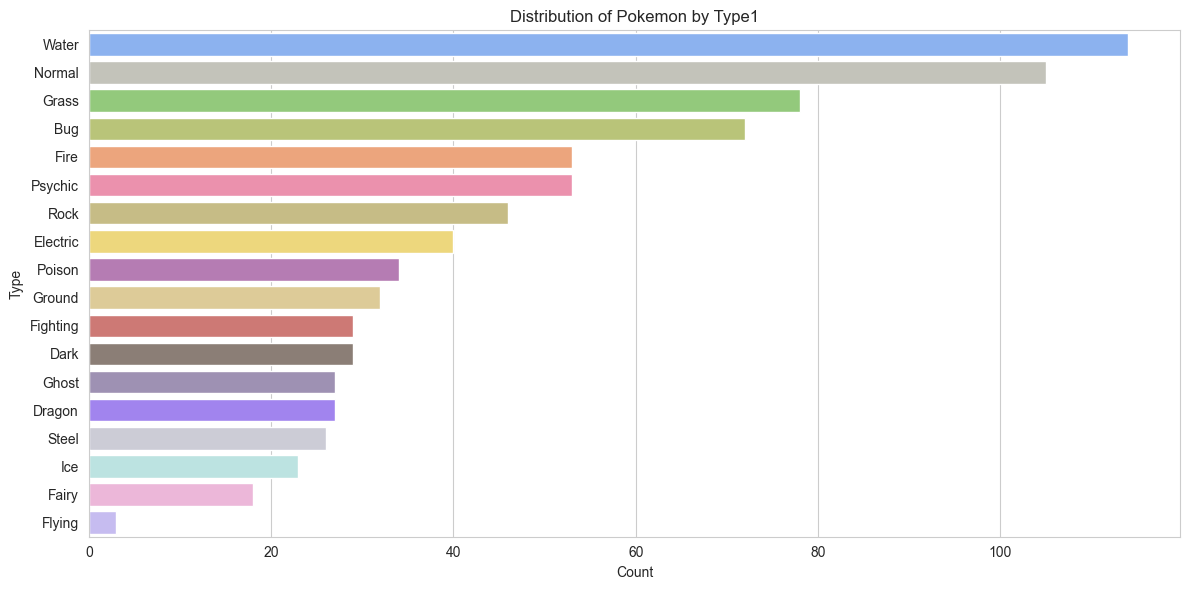

In [23]:
# visualisation for type1
colours1 = [typecolours[t] for t in type1pct.index]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=type1.values, y=type1.index, palette=colours1, ax=ax)
plt.title("Distribution of Pokemon by Type1")
plt.xlabel("Count")
plt.ylabel("Type")
plt.tight_layout()
plt.show()

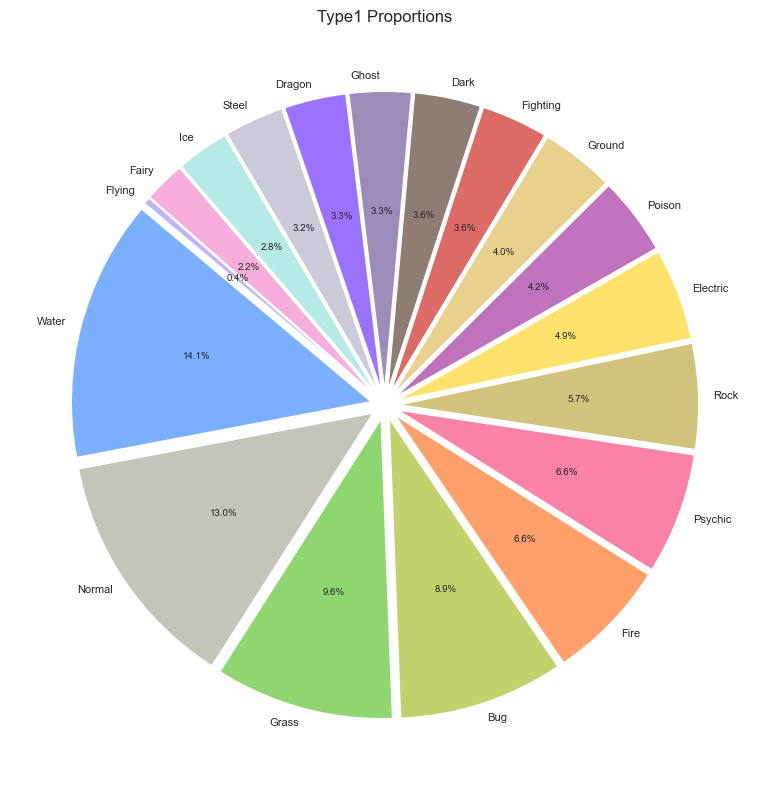

In [24]:
ax = plt.figure(figsize=(12, 8))
_, txtlabels, autotxt = plt.pie(type1pct, labels=type1pct.index, labeldistance = 1.05, autopct='%1.1f%%', startangle=140, colors=colours1, explode = [0.047] * len(type1pct))
for txt1 in txtlabels:
    txt1.set_fontsize(8)
for txt2 in autotxt:
    txt2.set_fontsize(7)
plt.title("Type1 Proportions")
plt.tight_layout()
plt.show()

In [25]:
print("Distribution of Pokemon by Type2:")
pd.DataFrame({"Count": type2, "Percentage": type2pct})

Distribution of Pokemon by Type2:


,Count,Percentage
Type2,,
Flying,95,23.46
Poison,32,7.90
Ground,32,7.90
Fairy,29,7.16
Psychic,29,7.16
Fighting,25,6.17
Steel,23,5.68
Grass,19,4.69
Dragon,18,4.44


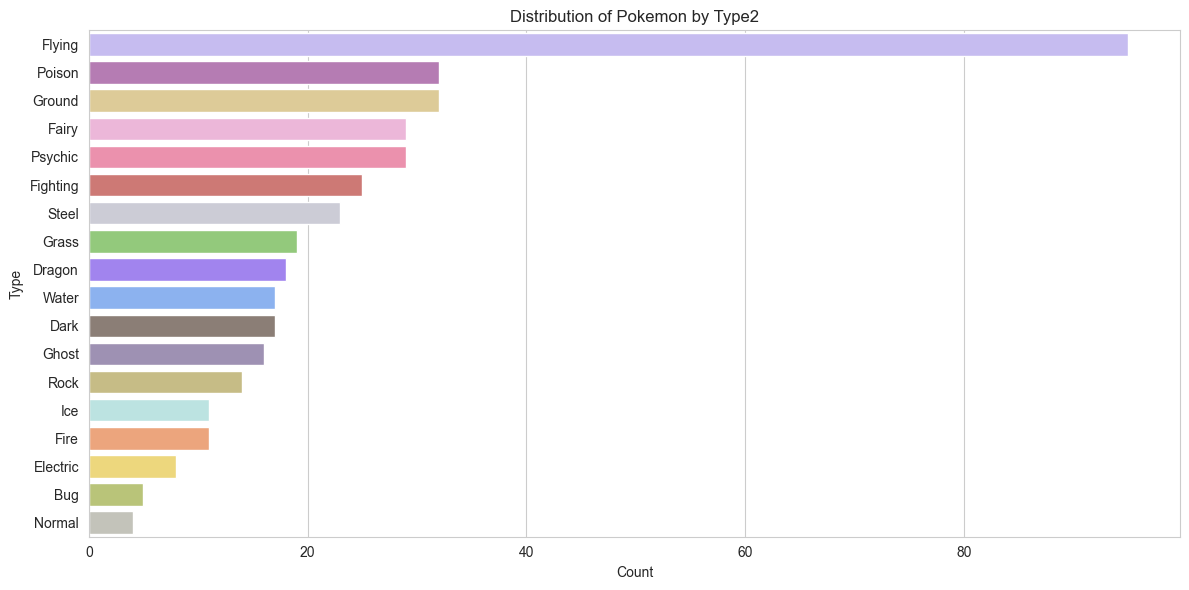

In [26]:
# visualisation for typ2
colours2 = [typecolours[t] for t in type2pct.index]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=type2.values, y=type2.index, palette=colours2, ax=ax)
plt.title("Distribution of Pokemon by Type2")
plt.xlabel("Count")
plt.ylabel("Type")
plt.tight_layout()
plt.show()

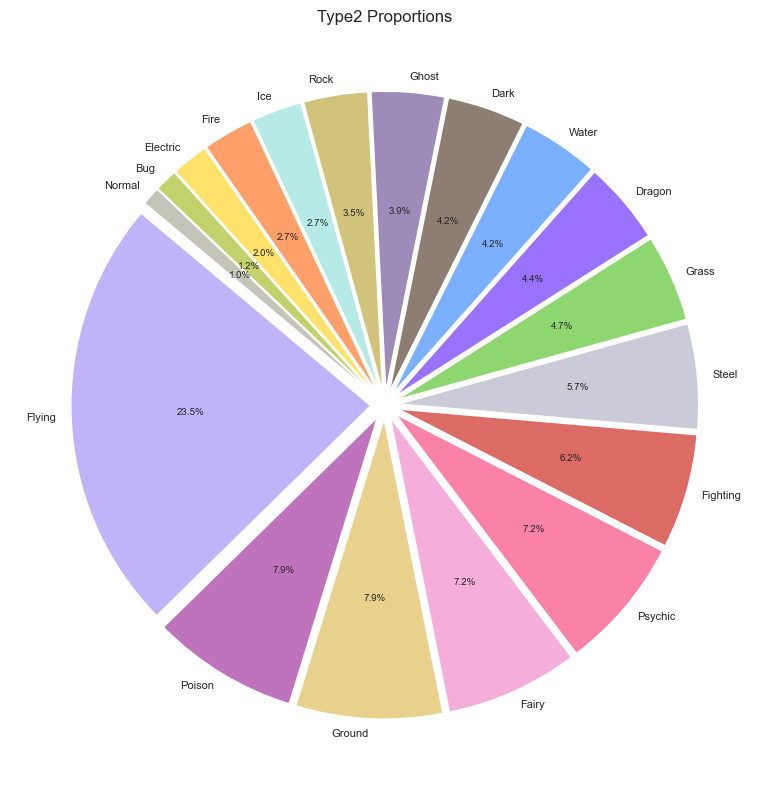

In [27]:
ax = plt.figure(figsize=(12, 8))
_, txtlabels, autotxt = plt.pie(type2pct, labels=type2pct.index, labeldistance = 1.05, autopct='%1.1f%%', startangle=140, colors=colours2, explode = [0.047] * len(type2pct))
for txt1 in txtlabels:
    txt1.set_fontsize(8)
for txt2 in autotxt:
    txt2.set_fontsize(7)
plt.title("Type2 Proportions")
plt.tight_layout()
plt.show()

In [28]:
# overlapping types
overlap = pd.DataFrame({"Type1 Count": type1, "Type2 Count": type2})
overlap["Type1 %"] = (overlap["Type1 Count"] / type1.sum() * 100).round(2)
overlap["Type2 %"] = (overlap["Type2 Count"] / type2.sum() * 100).round(2)
print("Overlapping Types:")
overlap

Overlapping Types:


,Type1 Count,Type2 Count,Type1 %,Type2 %
Bug,72,5,8.90,1.23
Dark,29,17,3.58,4.20
Dragon,27,18,3.34,4.44
Electric,40,8,4.94,1.98
Fairy,18,29,2.22,7.16
Fighting,29,25,3.58,6.17
Fire,53,11,6.55,2.72
Flying,3,95,0.37,23.46
Ghost,27,16,3.34,3.95
Grass,78,19,9.64,4.69
